In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Using FakeMarrakesh to simulate IBM quantum hardware locally
backend = FakeMarrakesh()

In [2]:
df = pd.read_csv('../data/cleaned/wildfire_cleaned.csv')

In [3]:
df.head()

,zip,year,fire_occurred,avg_tmax_c,avg_tmin_c,tot_prcp_mm,prev_year_fire,prev_year_acres,rolling_3yr_fire_count
0,85364,2020,1,23.938875,10.715056,241.85,0,0.0,0.0
1,89029,2020,1,23.938875,10.715056,241.85,0,0.0,0.0
2,89029,2022,0,23.938875,10.715056,241.85,0,0.0,1.0
3,89439,2019,1,23.938875,10.715056,241.85,0,0.0,0.0
4,89439,2023,0,23.938875,10.715056,241.85,0,0.0,0.0


In [4]:
test_2023 = df[df["year"] == 2023] # Saving 2023 data to be compared later
df = df[df["year"].between(2018, 2022)].reset_index(drop=True)

assert "fire_occurred" in df.columns, "Missing target column!"
assert df["fire_occurred"].isin([0, 1]).all(), "Target column has non-binary values!"
assert df.duplicated(subset=["year", "zip"]).sum() == 0, "Duplicate Year+ZIP rows found!"
assert df["avg_tmax_c"].isnull().sum() == 0, "Null values found in weather features!"

print("Shape:", df.shape)
print("Years:", sorted(df["year"].unique()))
print("Unique ZIPs:", df["zip"].nunique())
print("Nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:")
print(df["fire_occurred"].value_counts())
print(f"Class imbalance ratio: {df['fire_occurred'].value_counts()[0] / df['fire_occurred'].value_counts()[1]:.1f}:1")

Shape: (3650, 9)
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Unique ZIPs: 2009
Nulls:
 Series([], dtype: int64)

Target distribution:
fire_occurred
0    2599
1    1051
Name: count, dtype: int64
Class imbalance ratio: 2.5:1


In [5]:
df["temp_range"] = df["avg_tmax_c"] - df["avg_tmin_c"]  # daily temperature swing
test_2023["temp_range"] = test_2023["avg_tmax_c"] - test_2023["avg_tmin_c"]

print("Final features:")
print(df.drop(columns=["fire_occurred"]).columns.tolist())
print("\nShape:", df.shape)

Final features:
['zip', 'year', 'avg_tmax_c', 'avg_tmin_c', 'tot_prcp_mm', 'prev_year_fire', 'prev_year_acres', 'rolling_3yr_fire_count', 'temp_range']

Shape: (3650, 10)


In [ ]:
train = df[df["year"] <= 2021]
test  = df[df["year"] == 2022]

train_fire    = train[train["fire_occurred"] == 1].sample(n = 200, random_state = 42) # prev: 100
train_no_fire = train[train["fire_occurred"] == 0].sample(n = 200, random_state = 42)
train = pd.concat([train_fire, train_no_fire]).reset_index(drop = True)

test_fire    = test[test["fire_occurred"] == 1].sample(n = 100, random_state = 42) # prev: 50
test_no_fire = test[test["fire_occurred"] == 0].sample(n = 100, random_state = 42)
test = pd.concat([test_fire, test_no_fire]).reset_index(drop = True)

X_train = train.drop(columns=["fire_occurred"])
y_train = train["fire_occurred"]

X_test = test.drop(columns=["fire_occurred"])
y_test = test["fire_occurred"]

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (400, 9) {1: 200, 0: 200}
Test: (200, 9) {1: 100, 0: 100}


In [7]:
FEATURES = [c for c in df.columns if c not in ["zip", "year", "fire_occurred"]]
X_train, y_train = train[FEATURES].values, train["fire_occurred"].values
X_test,  y_test  = test[FEATURES].values,  test["fire_occurred"].values

print("\nTrain shape:", X_train.shape)
print("Test shape: ", X_test.shape)


Train shape: (400, 7)
Test shape:  (200, 7)


In [ ]:
# RandomForest to rank feature importance
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index = FEATURES).sort_values(ascending = False)
print("\nFeature importances:\n", importances)

TOP_N = 6
top_features = importances.head(TOP_N).index.tolist()
print(f"\nTop {TOP_N} features selected:", top_features)
X_train = train[top_features].values
X_test  = test[top_features].values

# Normalize to [-π, π] for quantum encoding
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nFeature range after scaling:")
print("  Min:", X_train.min().round(3), " Max:", X_train.max().round(3))


Feature importances:
 avg_tmin_c                0.282184
avg_tmax_c                0.194658
tot_prcp_mm               0.190895
temp_range                0.178285
rolling_3yr_fire_count    0.082434
prev_year_acres           0.043952
prev_year_fire            0.027592
dtype: float64

Top 6 features selected: ['avg_tmin_c', 'avg_tmax_c', 'tot_prcp_mm', 'temp_range', 'rolling_3yr_fire_count', 'prev_year_acres']

Feature range after scaling:
  Min: -3.142  Max: 3.142


In [ ]:
NUM_QUBITS = 8

feature_map = zz_feature_map(
    feature_dimension = 6,
    reps = 2, 
    entanglement = "linear"
)

print(f"Number of qubits : {feature_map.num_qubits}")
print(f"Circuit depth    : {feature_map.decompose().depth()}")
print(f"Number of params : {feature_map.num_parameters}")
print()
feature_map.decompose().draw("text")

Number of qubits : 6
Circuit depth    : 25
Number of params : 6



┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
4: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[4]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
5: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[5]) ├─────────────────────────────────────────»
   └────────────┘└───────────────┘                                         »
«        ┌────────────┐         ┌───────────────┐                             »
«0: ──■──┤ U(π/2,0,π) ├─────────┤ U(0,0,2*x[0]) ├─────────────────────────────»
«   ┌─┴─┐└────────────┘         └───────────────┘               ┌────────────┐»
«1: ┤ X ├──────■─────────────────────────────────────────────■──┤ U(π/2,0,π) ├»
«   └───┘    ┌─┴─┐     ┌──────────────────────────────────┐┌─┴─┐└────────────┘»
«2: ─────────┤ X ├─────┤ U(0,0,(-π + x[1])*(-π + x[2])*2) ├┤ X ├──────■───────»
«            └───┘     └──────────────────────────────────┘└───┘    ┌─┴─┐     »
«3: ────────────────────────────────────────────────────────────────┤ X ├─────»
«                                                                   └───┘     »
«4: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«5: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«                                            »
«0: ──────────────────────────────────────■──»
«            ┌───────────────┐          ┌─┴─┐»
«1: ─────────┤ U(0,0,2*x[1]) ├──────────┤ X ├»
«            └───────────────┘          └───┘»
«2: ──────────────────────────────────────■──»
«   ┌──────────────────────────────────┐┌─┴─┐»
«3: ┤ U(0,0,(-π + x[2])*(-π + x[3])*2) ├┤ X ├»
«   └──────────────────────────────────┘└───┘»
«4: ─────────────────────────────────────────»
«                                            »
«5: ─────────────────────────────────────────»
«                                            »
«                                                                           »
«0: ─────────────────────────────────────────────────────■──────────────────»
«   ┌──────────────────────────────────┐               ┌─┴─┐                »
«1: ┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├───────────────┤ X ├────────────────»
«   └──────────┬────────────┬──────────┘         ┌─────┴───┴─────┐          »
«2: ───────────┤ U(π/2,0,π) ├────────────────────┤ U(0,0,2*x[2]) ├──────────»
«              └────────────┘                    └───────────────┘          »
«3: ─────────────────■──────────────────────────────────────────────────────»
«                  ┌─┴─┐                ┌──────────────────────────────────┐»
«4: ───────────────┤ X ├────────────────┤ U(0,0,(-π + x[3])*(-π + x[4])*2) ├»
«                  └───┘                └──────────────────────────────────┘»
«5: ────────────────────────────────────────────────────────────────────────»
«                                                                           »
«                                            »
«0: ─────────────────────────────────────────»
«                                            »
«1: ──■──────────────────────────────────────»
«   ┌─┴─┐┌──────────────────────────────────┐»
«2: ┤ X ├┤ U(0,0,(-π + x[1])*(-π + x[2])*2) ├»
«   └───┘└──────────┬────────────┬──────────┘»
«3: ──■─

In [ ]:
sampler  = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map = feature_map,
    fidelity = fidelity
)

model = SVC(
    kernel = 'rbf',
    probability = False,  
    class_weight = 'balanced',
    random_state = 42
)

quantum_model = SVC(
    kernel = quantum_kernel.evaluate,
    probability = True,  
    class_weight = 'balanced',
    random_state = 42
)

In [18]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, pred)
class_report = classification_report(y_test, pred, zero_division = 0)
balanced_accuracy = balanced_accuracy_score(y_test, pred)
fl_weighted = f1_score(y_test, pred, average = 'weighted')
f1_macro = f1_score(y_test, pred, average = 'macro')

print(class_report)
print(f'Balanced Accuracy: {balanced_accuracy}')
print(f'F1-Weighted: {fl_weighted}')
print(f'F1-Macro: {f1_macro}')
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.82      0.73      0.77       100
           1       0.76      0.84      0.80       100

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.79      0.78       200

Balanced Accuracy: 0.7849999999999999
F1-Weighted: 0.7843476516462298
F1-Macro: 0.7843476516462298
[[73 27]
 [16 84]]


In [13]:
quantum_model.fit(X_train, y_train)
quantum_pred = quantum_model.predict(X_test)
quantum_prob = quantum_model.predict_proba(X_test)[:, 1]

In [14]:
conf_matrix = confusion_matrix(y_test, quantum_pred)
class_report = classification_report(y_test, quantum_pred, zero_division = 0)
balanced_accuracy = balanced_accuracy_score(y_test, quantum_pred)
fl_weighted = f1_score(y_test, quantum_pred, average = 'weighted')
f1_macro = f1_score(y_test, quantum_pred, average = 'macro')
roc_auc = roc_auc_score(y_test, quantum_prob)

print(class_report)
print(f"ROC-AUC: {roc_auc}")
print(f'Balanced Accuracy: {balanced_accuracy}')
print(f'F1-Weighted: {fl_weighted}')
print(f'F1-Macro: {f1_macro}')

print(conf_matrix)

              precision    recall  f1-score   support

           0       0.80      0.43      0.56       100
           1       0.61      0.89      0.72       100

    accuracy                           0.66       200
   macro avg       0.70      0.66      0.64       200
weighted avg       0.70      0.66      0.64       200

ROC-AUC: 0.7848
Balanced Accuracy: 0.66
F1-Weighted: 0.6410093971069581
F1-Macro: 0.6410093971069581
[[43 57]
 [11 89]]


In [ ]:
test_2023_subset = test_2023.sample(n = 200, random_state = 42).reset_index(drop = True)

# Prepare 2023 feature data
X_2023 = test_2023_subset[top_features].values
X_2023 = scaler.transform(X_2023)

# Generate risk scores
risk_scores = quantum_model.predict_proba(X_2023)[:, 1]
risk_labels = quantum_model.predict(X_2023)

# Build results dataframe
results_2023 = pd.DataFrame({
    "zip": test_2023_subset["zip"].values,
    "risk_score": risk_scores,
    "wildfire_predicted": risk_labels
})

results_2023 = results_2023.sort_values("risk_score", ascending = False).reset_index(drop = True)

print("2023 Predictions:")
print(f"ZIPs predicted as high risk: {risk_labels.sum()}")
print(f"ZIPs predicted as low risk:  {(risk_labels == 0).sum()}")
print("\nTop 10 highest risk ZIPs:")
print(results_2023.head(10))

2023 Predictions:
ZIPs predicted as high risk: 49
ZIPs predicted as low risk:  151

Top 10 highest risk ZIPs:
     zip  risk_score  wildfire_predicted
0  95457    0.848004                   1
1  95428    0.840990                   1
2  92332    0.834122                   1
3  93908    0.833070                   1
4  95669    0.828924                   1
5  92019    0.827693                   1
6  95412    0.819913                   1
7  93602    0.817191                   1
8  93240    0.795333                   1
9  94952    0.790207                   1


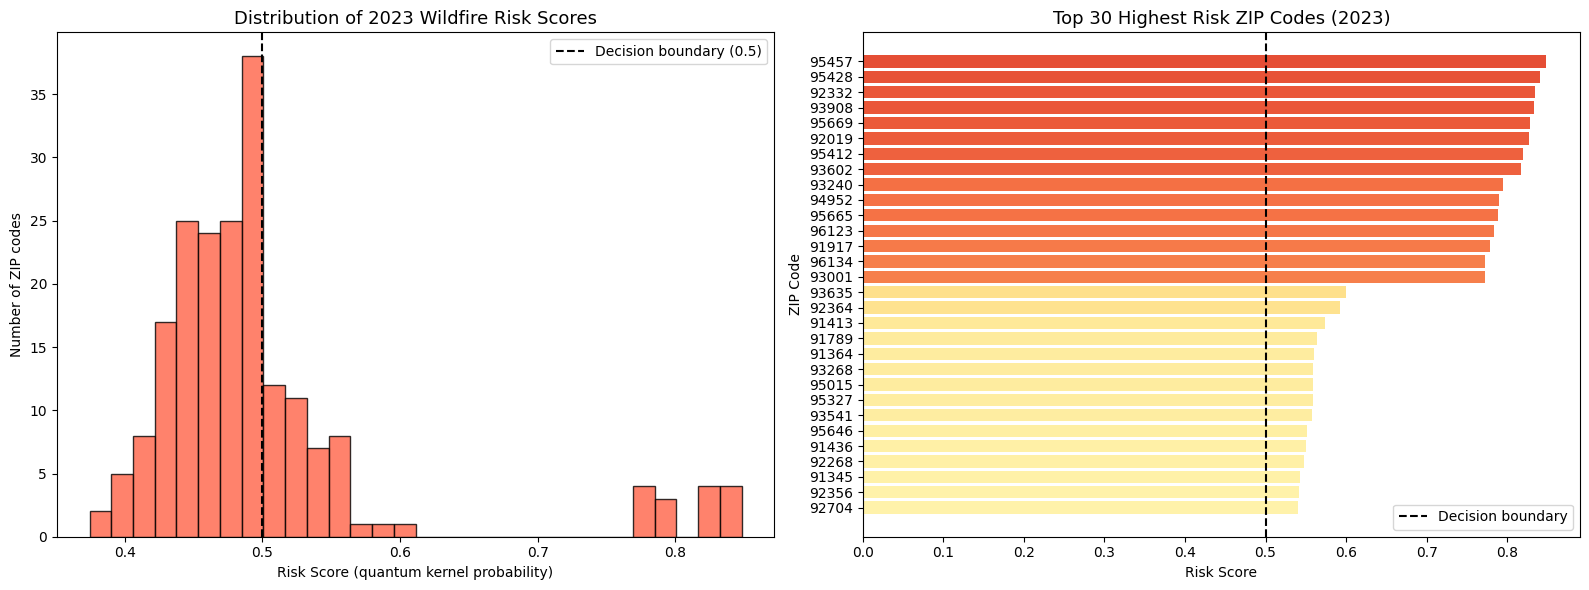

Saved to wildfire_risk_2023.png


In [ ]:
# Sort ZIPs by risk score for visualization
results_sorted = results_2023.sort_values("risk_score", ascending = False).reset_index(drop = True)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Risk score distribution
axes[0].hist(results_2023["risk_score"], bins = 30, color = "tomato", edgecolor = "black", alpha = 0.8)
axes[0].axvline(x = 0.5, color = "black", linestyle = "--", label = "Decision boundary (0.5)")
axes[0].set_title("Distribution of 2023 Wildfire Risk Scores", fontsize = 13)
axes[0].set_xlabel("Risk Score (quantum kernel probability)")
axes[0].set_ylabel("Number of ZIP codes")
axes[0].legend()

# Top 30 highest risk ZIPs
top30 = results_sorted.head(30)
colors = cm.RdYlGn_r(top30["risk_score"].values)
bars = axes[1].barh(top30["zip"].astype(str), top30["risk_score"], color = colors)
axes[1].axvline(x = 0.5, color = "black", linestyle = "--", label = "Decision boundary")
axes[1].set_title("Top 30 Highest Risk ZIP Codes (2023)", fontsize = 13)
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("ZIP Code")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig("wildfire_risk_scores.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("Saved to wildfire_risk_scores.png")